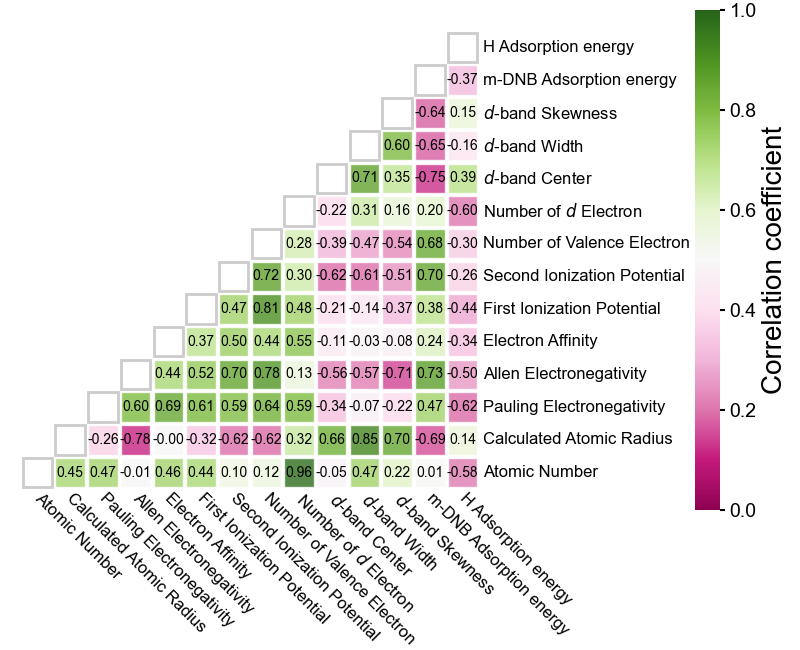

In [5]:
# region: import
import os, sys, yaml
import ipynbname
import numpy, copy, pandas
import matplotlib.pyplot
import pyexp
import pyexp.api.raman
import matplotlib.patches
import sys
path_folder_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if path_folder_root not in sys.path: sys.path.append(path_folder_root)
from conf.conf import dict_conf_cata_default
%matplotlib widget
# endregion

# region: conf
# header 
str_yaml = open('./dats/dict_header.yaml').read()
dict_header = yaml.load(str_yaml, Loader=yaml.FullLoader)
# endregion

# region: read data
mat_coef_spearman = numpy.load('./dats/mat_coef_spearman.npy', )
# endregion

# region: fig
fig, ax = pyexp.initial_fig_ax(
    figsize=[8, 6.5], 
    flag_enable_spine=False, left=0.0, right=3, bottom=1.4, )
ax.set_aspect('equal')
# ax.set_yscale('log')  
# ax.set_ylabel('PCA score', fontsize=pyexp.dict_conf_fontsize['label'])
# endregion

# region: fill
# fill
len_rect = 0.9
cmap = matplotlib.pyplot.cm.PiYG
for ii in range(mat_coef_spearman.shape[0]):
    for jj in range(mat_coef_spearman.shape[1]):
        scale_color = (mat_coef_spearman[ii][jj] + 1) / 2
        xx_fill_bias =  ii
        yy_fill_bias = jj
        xx_fill = numpy.array(
            [len_rect/2, len_rect/2, -len_rect/2, -len_rect/2])
        yy_fill = numpy.array(
            [-len_rect/2, len_rect/2, len_rect/2, -len_rect/2])
        if ii > jj:
            ax.fill(
                xx_fill+xx_fill_bias, yy_fill+yy_fill_bias, 
                alpha=0.8, color=cmap(scale_color), edgecolor='w')
            # debug
            if True:
                ax.text(
                    x=xx_fill_bias, y=yy_fill_bias, s='%.2f'%mat_coef_spearman[ii][jj], 
                    va='center', ha='center',  fontsize=10)
        elif ii == jj:
            ax.fill(
                xx_fill+xx_fill_bias, yy_fill+yy_fill_bias, 
                alpha=0.2, edgecolor='k', facecolor='none', linewidth=2)
# label
# make array_label_x full name
for ii, name_header in enumerate(list(dict_header.keys())[1::]):
    label_x_fullname = dict_header[name_header]['label']
    ax.text(
        x=ii-0.2*len_rect, y=-0.6*len_rect, s=label_x_fullname, 
        va='top', ha='left', rotation=-45, fontsize=12)
    ax.text(
         x=mat_coef_spearman.shape[0]-1+0.7*len_rect, y=ii, s=label_x_fullname, 
         va='center', ha='left', rotation=0, fontsize=12)
# endregion
           
# region: cax
cax = pyexp.add_cbar(
    fig=fig, left=6.95, right=0.8, bottom=1.4, top=0.1, 
    cmap=cmap, flag_enable_spine=False, )
cax.set_label('Correlation coefficient', fontsize=pyexp.dict_conf_fontsize['label'])
# endregion

# region: save
pyexp.save_fig(fig=fig)
# endregion